#Credit Card Fraud Detection Using Machine Learning

A Machine Learning project developed using Python and Scikit-learn to detect fraudulent credit card transactions based on transaction features and classification algorithms



In [1]:
#IMPORTING LIBRARIES
import pandas as pd
import numpy as np

In [4]:
#LOADING DATASET
df = pd.read_csv("/content/creditcard.csv (1).zip")

In [5]:
#DISPLAYING THE DATASET
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
#DISPLAYING INFORMATION ABOUT THE DATASET
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [7]:
#IDENTIFYING THE MISSING VALUE
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [8]:
#IMPORTING VISUALIZATION LIBRARIES
import matplotlib.pyplot as plt
import seaborn as sns

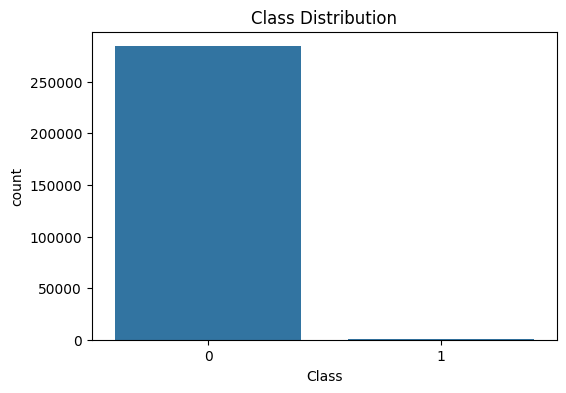

In [9]:
#CLASS DISTRIBUTION VISUALIZAION
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title("Class Distribution")
plt.show()

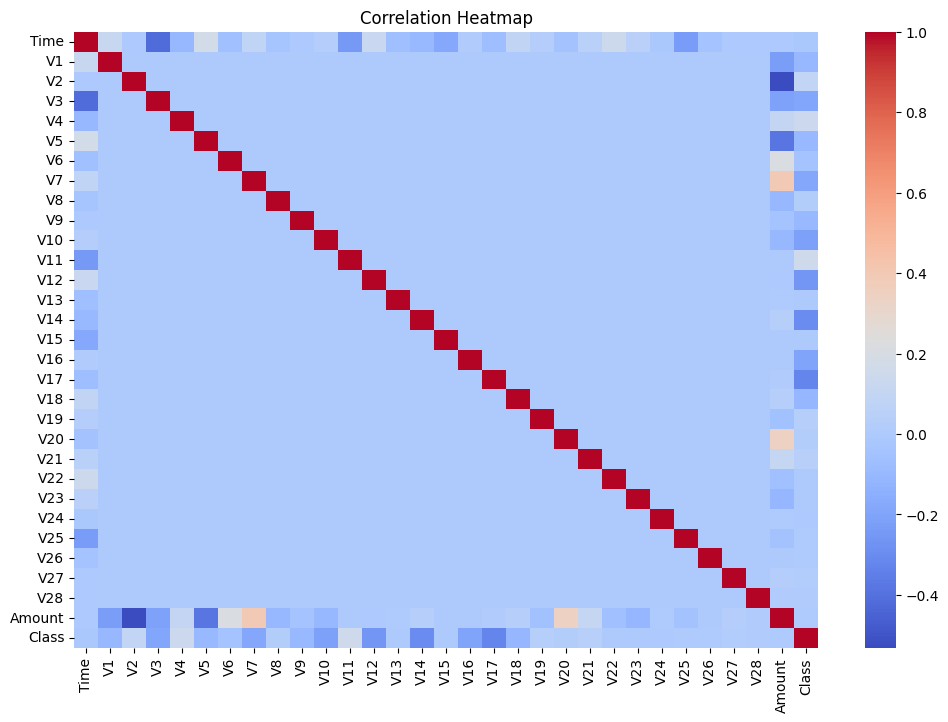

In [10]:
#CORRELATION ANALYSIS
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [11]:
#IMPORTING STANDARDSCALER
from sklearn.preprocessing import StandardScaler

In [12]:
#FEATURE SCALING
scaler = StandardScaler()
df['Time'] = scaler.fit_transform(df[['Time']])
df['Amount'] = scaler.fit_transform(df[['Amount']])

In [13]:
#FEATURE AND TARGET SEPERATION
X = df.drop('Class', axis=1)
y = df['Class']

In [14]:
#IMPORTING SMOTE
from imblearn.over_sampling import SMOTE

In [15]:
#HANDLING CLASS IMBALANCE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

In [16]:
#IMPORTING TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split

In [17]:
#TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42
)

In [18]:
#IMPORTING LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression

In [19]:
#LOGISTIC REGRESSION
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

In [20]:
#IMPORTING EVALUTION MATRIX
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [21]:
#EVALUTION
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))

Accuracy: 0.9489035049153228
Precision: 0.9743737135863821
Recall: 0.9222655153046897
F1 Score: 0.9476038050583833


In [22]:
#IMPORTING RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier

In [23]:
#RANDOM FOREST
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [24]:
#MODEL COMPARISION
results = pd.DataFrame({
    'Model':['Logistic Regression','Random Forest'],
    'Accuracy':[
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_rf)
    ]
})
results

,Model,Accuracy
0,Logistic Regression,0.948904
1,Random Forest,0.999903


In [25]:
#CLASSIFICATION REPORT FOR RANDOM FOREST
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56750
           1       1.00      1.00      1.00     56976

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726



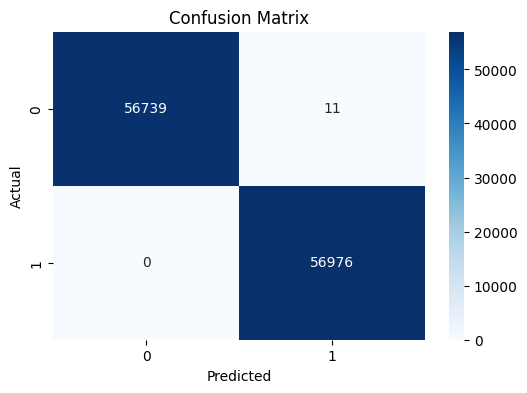

In [26]:
#CONFUSION MATRIX
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

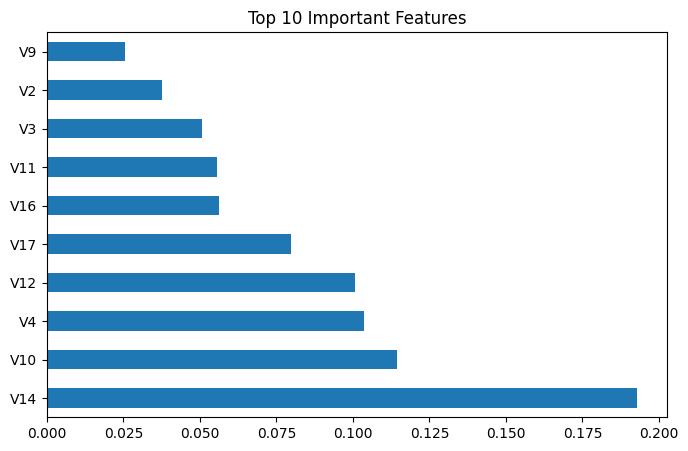

In [27]:
#FEATURE IMPORTANCE
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)
importance.nlargest(10).plot(
    kind='barh',
    figsize=(8,5)
)
plt.title("Top 10 Important Features")
plt.show()